# Кластерный анализ данных

Датасет Credit Card Dataset for Clustering - задача сегментации клиентов в банке
- много признаков + признаки могут иметь большой разброс - нужна масштабируемость

Требуется выделить сегменты клиентов в зависимости от их поведенческих паттернов, представленных в наборе данных, чтобы сфокусировать маркетинговую стратегию компании на конкретном сегменте.

###Признаки
- CUST_ID - Идентификатор клиента
- BALANCE - Остаток на счёте
- BALANCE_FREQUENCY - Частота обновления баланса
- PURCHASES - Сумма покупок
- ONEOFF_PURCHASES - Разовые покупки (без рассрочки)
- INSTALLMENTS_PURCHASES - Покупки в рассрочку
- CASH_ADVANCE - Общая сумма снятых наличных
- PURCHASES_FREQUENCY - Частота покупок
- ONEOFF_PURCHASES_FREQUENCY - Частота разовых (без рассрочки)
- PURCHASES_INSTALLMENTS_FREQUENCY - Частота покупок в рассрочку
- CASH_ADVANCE_FREQUENCY - Частота снятия наличных
- CASH_ADVANCE_TRX - Количество операций снятия наличных
- PURCHASES_TRX - Количество покупок
- CREDIT_LIMIT - Кредитный лимит
- PAYMENTS - Сумма платежей для погашения долга
- MINIMUM_PAYMENTS - Минимальные обязательные платежи
- PRC_FULL_PAYMENT - Процент месяцев, в которых клиент погасил задолженность полностью (а не минимальным платежом)
- TENURE - Срок обслуживания

In [ ]:
!pip install openml -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openml

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

import warnings
warnings.filterwarnings('ignore')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 26.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Загрузка датасета "Credit Card Dataset for Clustering"
file_path = '/content/drive/My Drive/credit_cards_dataset.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Датасет успешно загружен! Размер: {df.shape}")
except FileNotFoundError:
    print("ОШИБКА: Файл не найден.")


Датасет успешно загружен! Размер: (8950, 18)


In [ ]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


У большинства признаков среднее значение намного выше медианного.  Это свидетельствует о некоторой асимметрии в наборе данных, и нам нужно понять, можно ли что-то с этим сделать.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


Присутствуют пропущенные значения. Их необходимо заполнить.

## Предобработка данных

Идентификатор клиента уникален для каждого и не несет информации для кластериации. Удаляем его из признаков.

In [ ]:
df.drop(['CUST_ID'], axis=1, inplace=True)

In [ ]:
# заполняем пропуски
df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)
df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)

Используем `медиану` для заполнения пропущенных значений, потому что распределение признаков `асимметрично`, значит `медиана` лучше отражает центральную тенденцию этой функции.

In [ ]:
dupes = df.duplicated().sum()
dupes

np.int64(0)

дубликаты не найдены

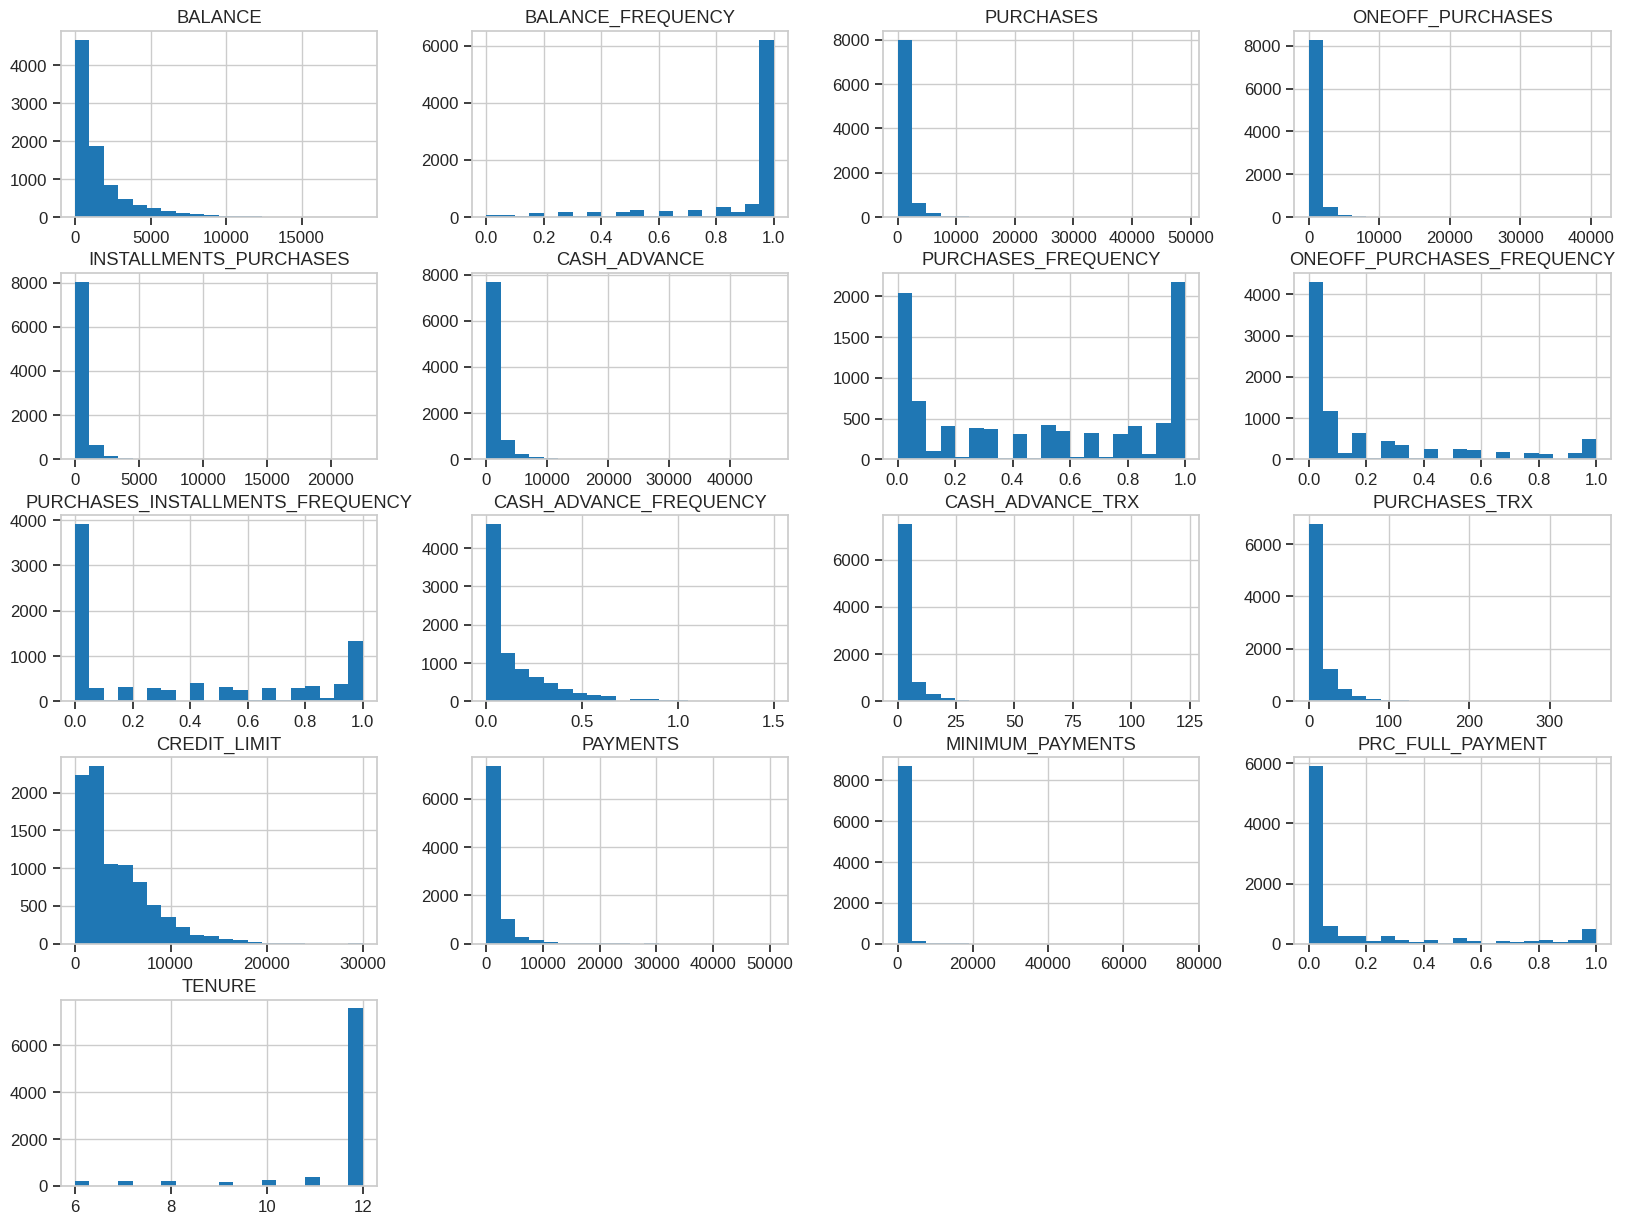

In [ ]:
df.hist(bins=20, figsize=(20, 15))
plt.show()

### Используем логарифмическое преобразование

Уменьшает асимметрию, сжимает выбросы, делает распределение более нормальным. Применимо как раз для правосторонне скошенных данных (финансовых). Но `не приводит` признаки к единому масштабу.

Логарифмировать будем скошенные денежные/счётные признаки. Частотные колонки не берем.


In [ ]:
log_cols = [
    'BALANCE',
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    'CASH_ADVANCE_TRX',
    'CREDIT_LIMIT',
    'PURCHASES_TRX'
]

for col in log_cols:
    df[col] = np.log(1 + df[col])

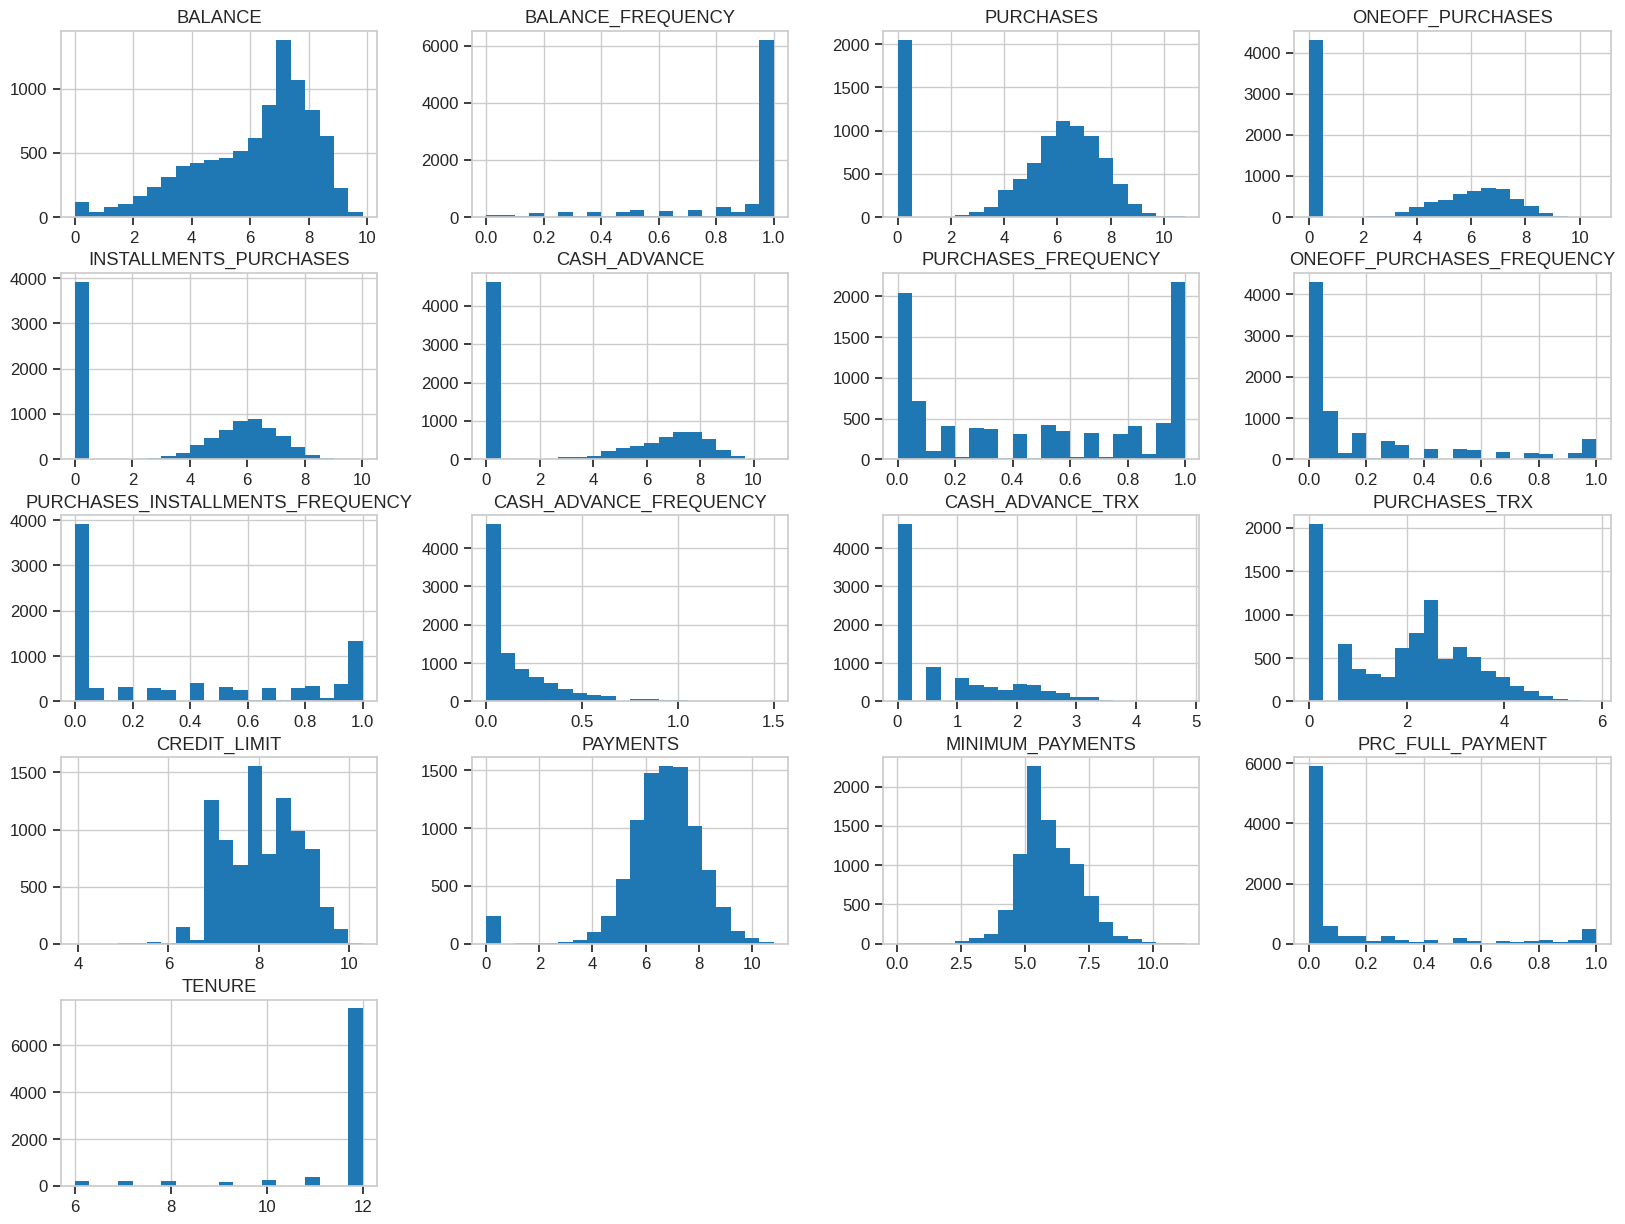

In [ ]:
df.hist(bins=20, figsize=(20, 15))
plt.show()

Нужно отобрать признаки для кластеризации. Посмотрим на карту корреляций.

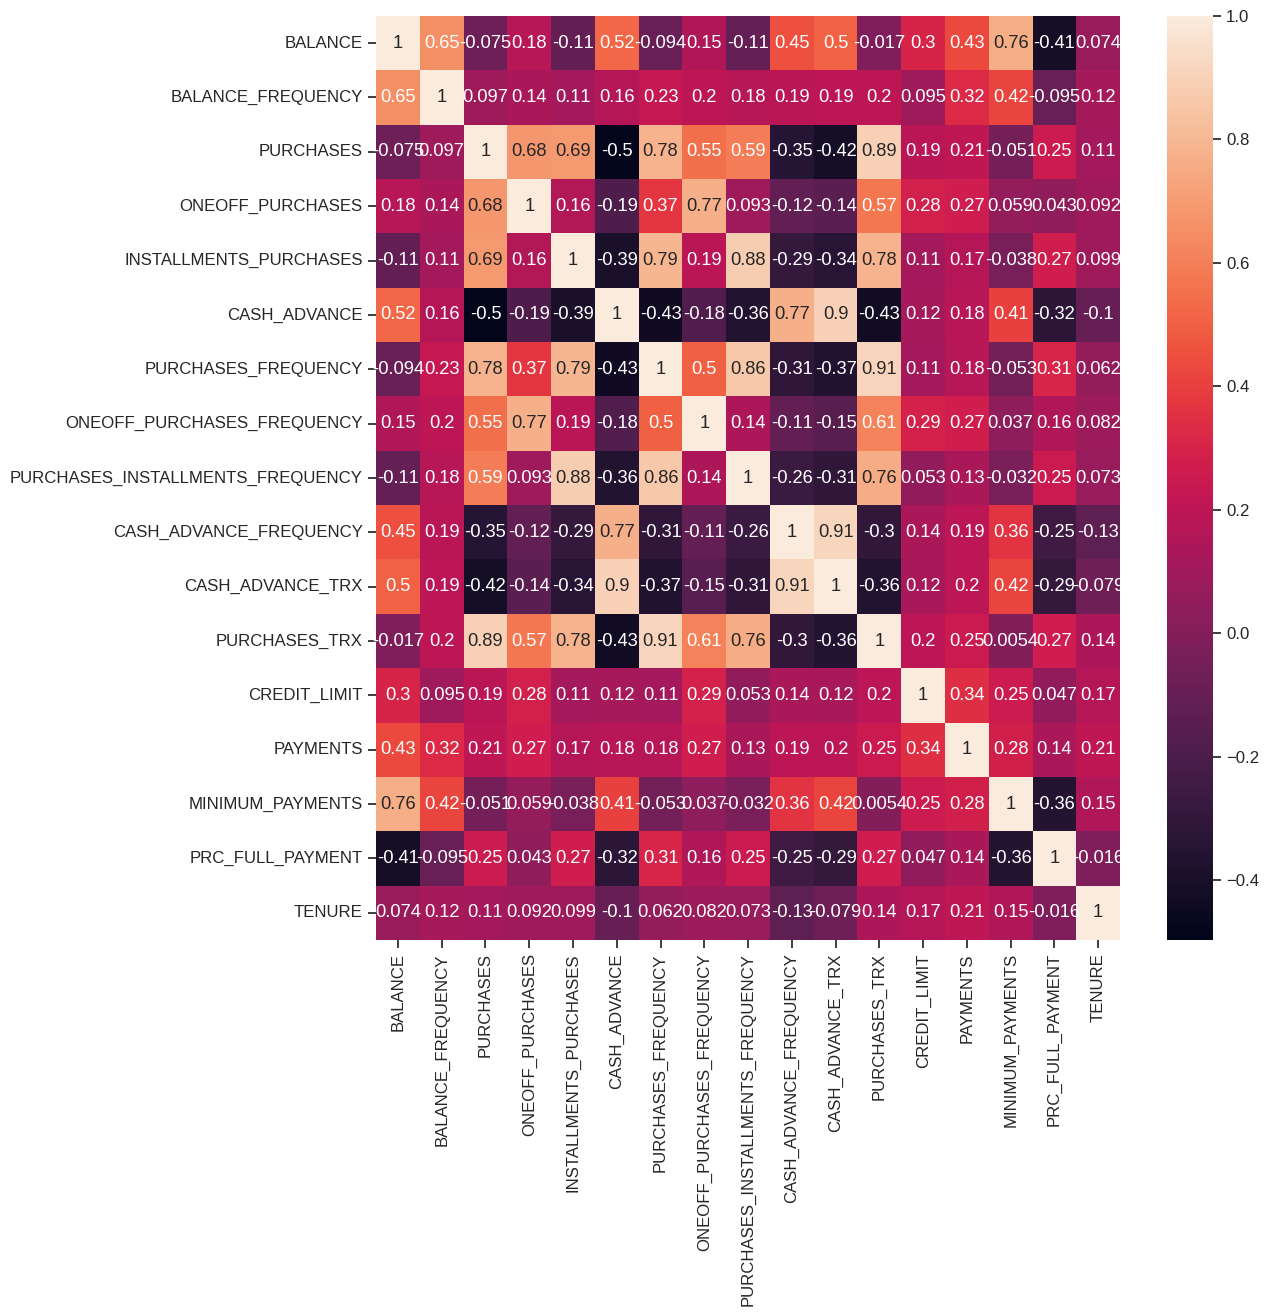

In [ ]:
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(), annot=True)
plt.show()

- `PURCHASES_TRX - PURCHASES = 0,89`  Количество покупок дублирует их сумму. Оставим `PURCHASES`, сумма покупок - важный показатель
- `PURCHASES_TRX - PURCHASES_FREQUENCY = 0,91` Частота покупок коррелирует с количеством. Оставим `PURCHASES_FREQUENCY`, так как частота позволяет судить о регулярности
- `CASH_ADVANCE_TRX - CASH_ADVANCE = 0,9` Число снятий коррелирует с суммой снятий. Оставим `CASH_ADVANCE`, более информативный показатель
- `CASH_ADVANCE_TRX - CASH_ADVANCE_FREQUENCY = 0,91` Количество снятий коррелирует с частотой. Оставим `CASH_ADVANCE_FREQUENCY`, так как клиент может снимать много и редко, либо мало и часто.
- `INSTALLMENTS_PURCHASES - PURCHASES_INSTALLMENTS_FREQUENCY = 0,88` Сумма и частота рассрочек дублируются. Оставляем `INSTALLMENTS_PURCHASES` сумма покупок в рассрочку информативнее
- `PURCHASES_FREQUENCY - PURCHASES_INSTALLMENTS_FREQUENCY = 0,86` Общая частота покупок коррелирует с частотой рассрочек. Оставляем `PURCHASES_FREQUENCY`, так как это более универсальный показатель активности клиента.

Мы должны оставить признаки из разных категорий для корректной сегментации.
Нам нужны и финансовые и частотные признаки, а также уникальные признаки, которые отражают платежеспособность, вовлеченность клиента и доверие банка клиенту и почти не коррелируют с остальными признаками.

Финансовые:
- `PURCHASES` - Общая сумма покупок
- `CASH_ADVANCE` - Сумма снятых наличных (риск)
- `INSTALLMENTS_PURCHASES` - Сумма покупок в рассрочку (хорошие клиенты для кредитования)

Частотные:
- `PURCHASES_FREQUENCY` - Частота совершения покупок
- `CASH_ADVANCE_FREQUENCY` - Частота снятия наличных

Платежеспособность и вовлеченность:
- `PRC_FULL_PAYMENT` - Процент месяцев, в которых клиент погасил задолженность полностью (а не минимальным платежом)

Отношения клиента и банка:
- `CREDIT_LIMIT` - Кредитный лимит, отражает доверие банка клиенту
- `TENURE` - Срок обслуживания, лояльность к клиенту

In [ ]:
selected_features = [
    'PURCHASES',
    'CASH_ADVANCE',
    'INSTALLMENTS_PURCHASES',

    'PURCHASES_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY',

    'PRC_FULL_PAYMENT',

    'CREDIT_LIMIT',
    'TENURE'
]

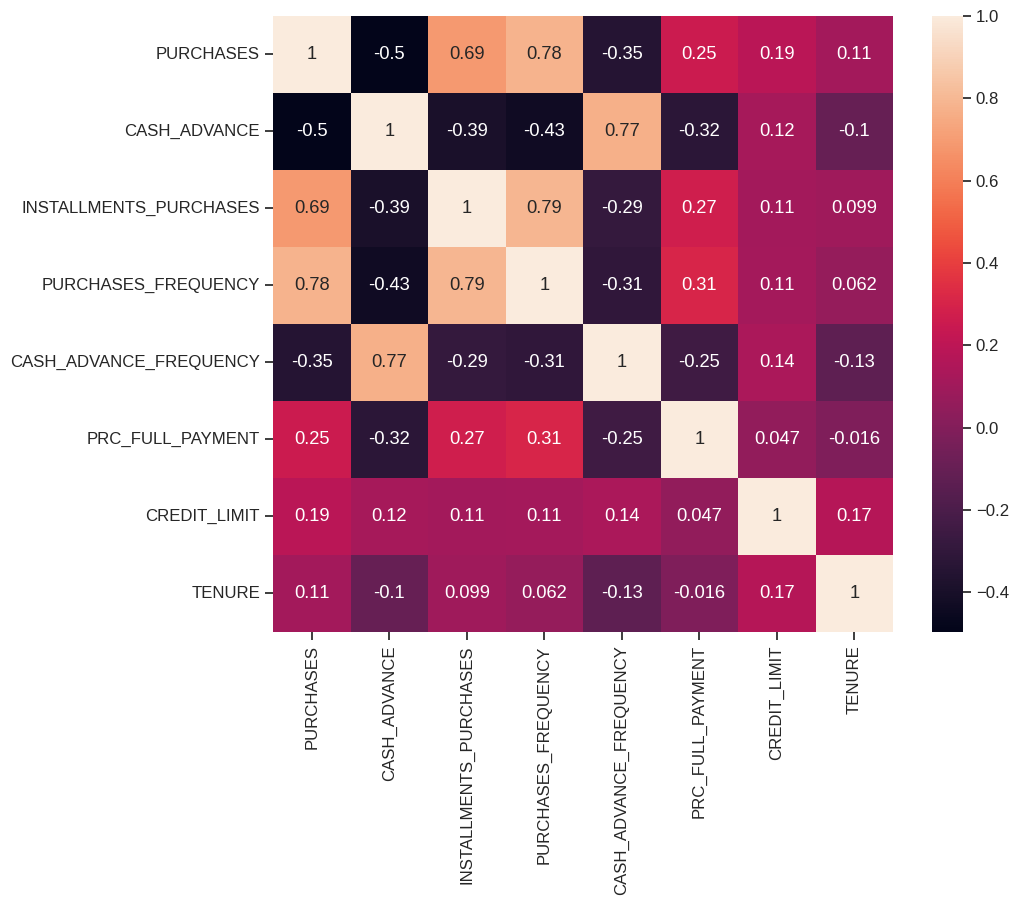

In [ ]:
plt.figure(figsize=(10, 8))
df_selected = df[selected_features]
sns.heatmap(df_selected.corr(), annot=True)
plt.show()

Признаки `PURCHASES_FREQUENCY` и `INSTALLMENTS_PURCHASES` имеют корреляцию 0.79, что указывает на связь между регулярностью использования карты и предпочтением покупок в рассрочку. Но оставим оба признака, так как это позволит нам лучше интерпретировать кластеры, ведь клиент может покупать часто и много в рассрочку, но если и клиенты которые покупают часто, но мелкими покупками без рассрочек, а есть и те, кто покупает не особо часто, но совершает крупные покупки в рассрочку.

In [ ]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_selected), columns=selected_features)

Визуализизация подготовленных данных.

Предиктивная аналитика количества и качества кластеров

Размерность после t-SNE: (8950, 2)


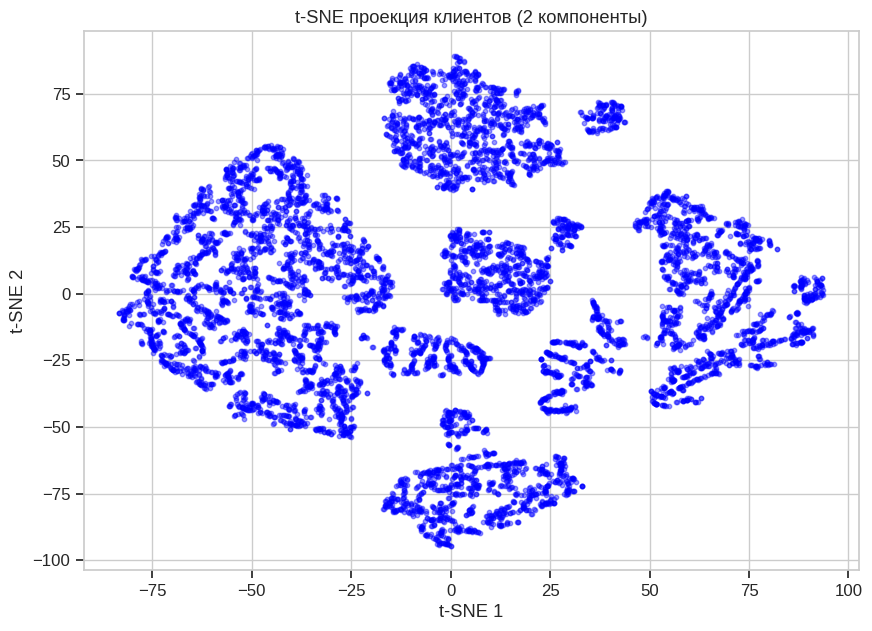

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(df_selected)

print(f"Размерность после t-SNE: {X_tsne.shape}")

plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c='blue', alpha=0.4, s=10)
plt.title('t-SNE проекция клиентов (2 компоненты)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True)
plt.show()

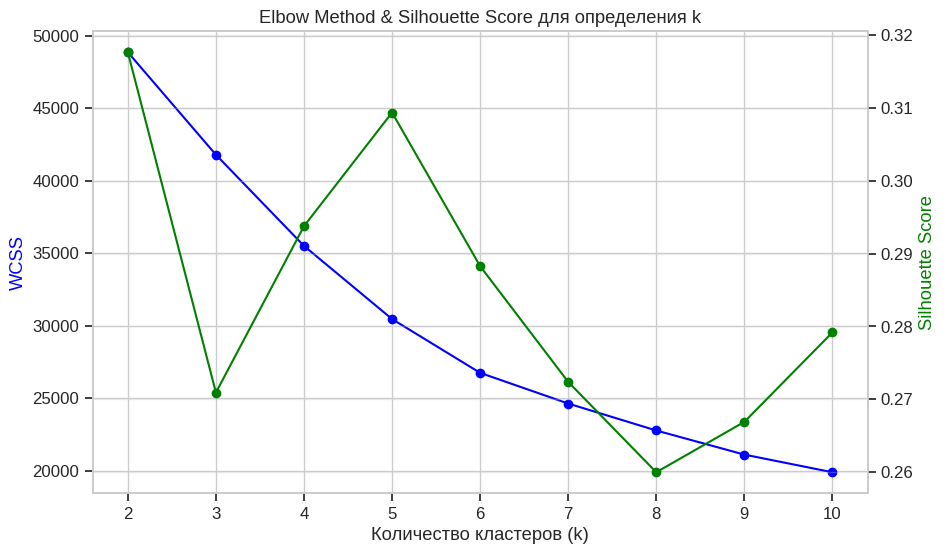

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []
range_k = range(2, 11)

for k in range_k:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Количество кластеров (k)')
ax1.set_ylabel('WCSS (Inertia)', color='blue')
ax1.plot(range_k, wcss, marker='o', color='blue', label='WCSS')
ax1.set_ylabel('WCSS', color='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='green')
ax2.plot(range_k, silhouette_scores, marker='o', color='green', label='Silhouette')

plt.title('Elbow Method & Silhouette Score для определения k')
plt.grid(True, alpha=0.3)
plt.show()

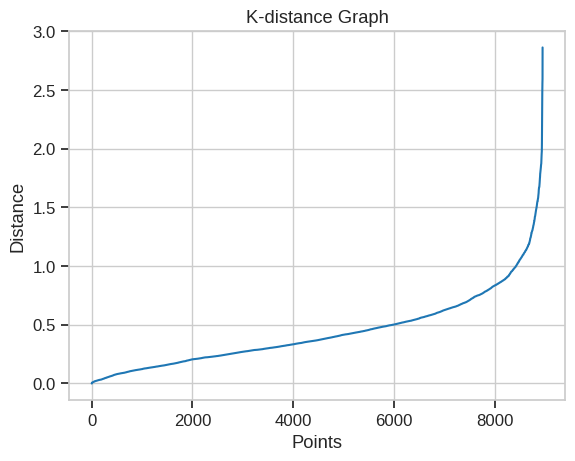

array([0.        , 0.        , 0.        , ..., 2.57797398, 2.59550698,
       2.86309137])

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# Метод k-distance graph для подбора eps
def find_optimal_eps(data, k=5):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(data)
    distances, indices = neighbors_fit.kneighbors(data)
    distances = np.sort(distances[:, k-1])

    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel('Distance')
    plt.title('K-distance Graph')
    plt.show()

    return distances

find_optimal_eps(df_scaled, k=5)

In [ ]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering

# K-Means
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(df_scaled)

# DBSCAN
dbscan = DBSCAN(eps=0.9, min_samples=10)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df_scaled)

# Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df['Agglo_Cluster'] = agglo.fit_predict(df_scaled)

print(f"K-Means: {df['KMeans_Cluster'].nunique()} кластеров")
print(f"DBSCAN: {df['DBSCAN_Cluster'].nunique() - (1 if -1 in df['DBSCAN_Cluster'].values else 0)} кластеров + шум(-1)")
print(f"Agglomerative: {df['Agglo_Cluster'].nunique()} кластеров")

K-Means: 5 кластеров
DBSCAN: 4 кластеров + шум(-1)
Agglomerative: 5 кластеров


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

def calc_metrics(data, labels):
    if -1 in labels:
        mask = labels != -1
        data = data[mask]
        labels = labels[mask]

    sil = silhouette_score(data, labels)
    db = davies_bouldin_score(data, labels)
    ch = calinski_harabasz_score(data, labels)
    return sil, db, ch

metrics = {
    'K-Means': calc_metrics(df_scaled, df['KMeans_Cluster'].values),
    'DBSCAN': calc_metrics(df_scaled, df['DBSCAN_Cluster'].values),
    'Agglomerative': calc_metrics(df_scaled, df['Agglo_Cluster'].values)
}

df_metrics = pd.DataFrame(metrics, index=['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'])
print("Сравнение метрик качества:")
print(df_metrics)

Сравнение метрик качества:
                       K-Means       DBSCAN  Agglomerative
Silhouette            0.309335     0.256141       0.276296
Davies-Bouldin        1.213610     1.122921       1.304507
Calinski-Harabasz  3020.541925  2223.522123    2648.790765


`Silhouette`: чем ближе к 1, тем лучше разделение кластеров. Отрицательные значения означают, что точки отнесены не к тому кластеру.

`Davies-Bouldin`: чем ближе к 0, тем лучше (меньше перекрытия кластеров).

`Calinski-Harabasz`: чем выше, тем плотнее кластеры и дальше друг от друга.

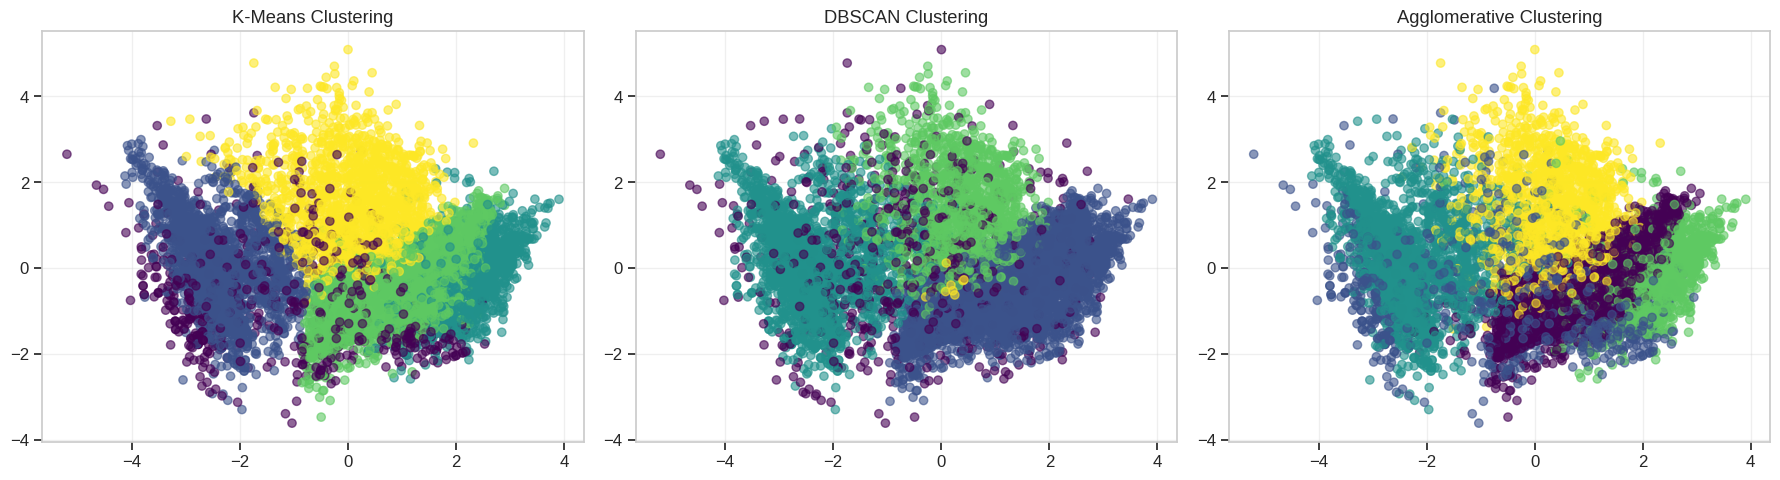

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
axes[0].scatter(df_pca[:, 0], df_pca[:, 1], c=df['KMeans_Cluster'], cmap='viridis', alpha=0.6)
axes[0].set_title('K-Means Clustering')

# DBSCAN
axes[1].scatter(df_pca[:, 0], df_pca[:, 1], c=df['DBSCAN_Cluster'], cmap='viridis', alpha=0.6)
axes[1].set_title('DBSCAN Clustering')

# Agglomerative
axes[2].scatter(df_pca[:, 0], df_pca[:, 1], c=df['Agglo_Cluster'], cmap='viridis', alpha=0.6)
axes[2].set_title('Agglomerative Clustering')

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

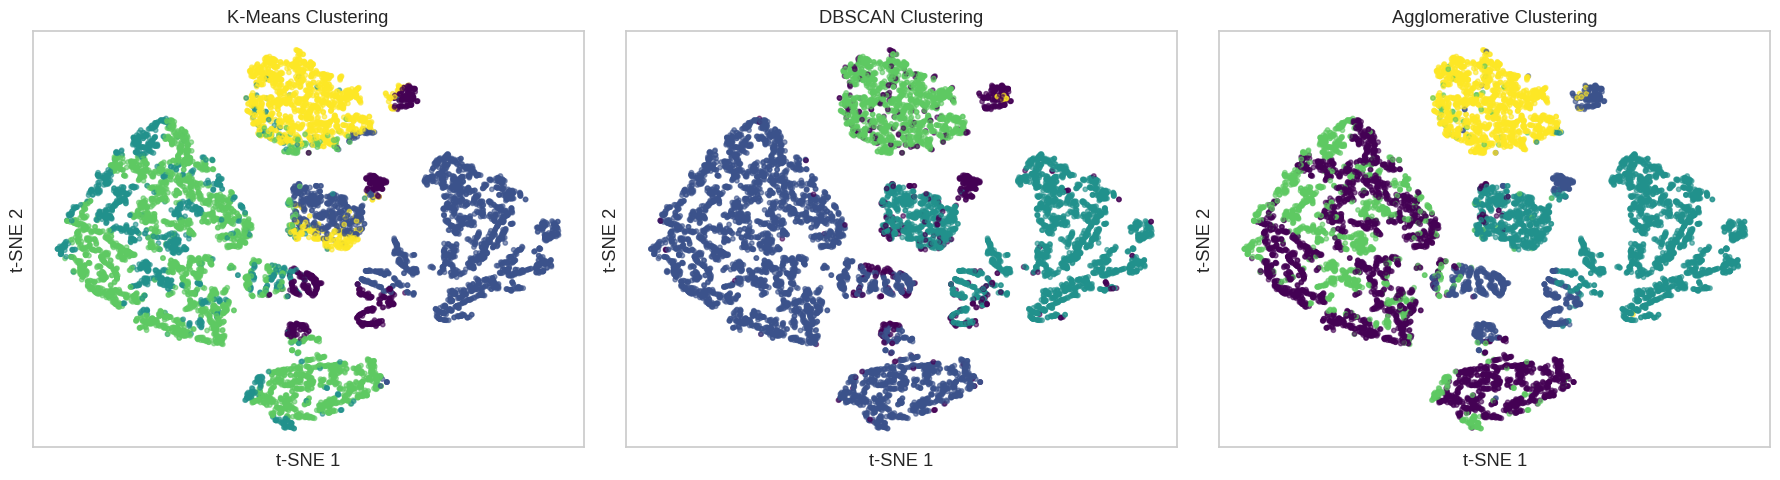

In [ ]:
# tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, learning_rate='auto')
# df_tsne = tsne.fit_transform(df_scaled)

# print(f"t-SNE выполнено за {time.time() - start_time:.2f} секунд")
# print(f"Размерность после t-SNE: {df_tsne.shape}")

# Визуализация результатов кластеризации в пространстве t-SNE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                          c=df['KMeans_Cluster'],
                          cmap='viridis',
                          alpha=0.6,
                          s=10)
axes[0].set_title('K-Means Clustering')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

# DBSCAN
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                          c=df['DBSCAN_Cluster'],
                          cmap='viridis',
                          alpha=0.6,
                          s=10)
axes[1].set_title('DBSCAN Clustering')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

# Agglomerative
scatter3 = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1],
                          c=df['Agglo_Cluster'],
                          cmap='viridis',
                          alpha=0.6,
                          s=10)
axes[2].set_title('Agglomerative Clustering')
axes[2].set_xlabel('t-SNE 1')
axes[2].set_ylabel('t-SNE 2')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
df_clusters = pd.DataFrame(scaler.inverse_transform(df_scaled), columns=selected_features)

log_cols = [
    'BALANCE',
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    'CASH_ADVANCE_TRX',
    'CREDIT_LIMIT',
    'PURCHASES_TRX'
]

for col in log_cols:
    if col in df_clusters.columns:
        df_clusters[col] = np.exp(df_clusters[col]) - 1

df_clusters['KMeans_Cluster'] = df['KMeans_Cluster']

cluster_centers = df_clusters.groupby('KMeans_Cluster').mean()
print("Характеристики кластеров (K-Means):")
print(cluster_centers.round(2))

Характеристики кластеров (K-Means):
                PURCHASES  CASH_ADVANCE  INSTALLMENTS_PURCHASES  \
KMeans_Cluster                                                    
0                  422.58       1307.35                  139.20   
1                   49.25       1928.63                    0.52   
2                 2038.92         26.63                  898.21   
3                 1158.95          4.78                  473.47   
4                 1579.58       2399.93                  643.80   

                PURCHASES_FREQUENCY  CASH_ADVANCE_FREQUENCY  PRC_FULL_PAYMENT  \
KMeans_Cluster                                                                  
0                              0.40                    0.22              0.13   
1                              0.03                    0.27              0.04   
2                              0.82                    0.00              0.79   
3                              0.61                    0.00              0.05   
4       

Финансовые:
- `PURCHASES` - Общая сумма покупок
- `CASH_ADVANCE` - Сумма снятых наличных (риск)
- `INSTALLMENTS_PURCHASES` - Сумма покупок в рассрочку (хорошие клиенты для кредитования)

Частотные:
- `PURCHASES_FREQUENCY` - Частота совершения покупок
- `CASH_ADVANCE_FREQUENCY` - Частота снятия наличных

Платежеспособность и вовлеченность:
- `PRC_FULL_PAYMENT` - Процент месяцев, в которых клиент погасил задолженность полностью (а не минимальным платежом)

Отношения клиента и банка:
- `CREDIT_LIMIT` - Кредитный лимит, отражает доверие банка клиенту
- `TENURE` - Срок обслуживания, лояльность к клиенту

- **Кластер 1** - **"Новые клиенты"** - низкое количество покупок, но довольно много снимают наличных, довольно редко берут в рассрочку. Чаще вносят только минимальный платеж, самый низкий кредитный лимит и срок обслуживания.

Новые клиенты с низким кредитным лимитом, которые чаще снимают наличные, чем совершают покупки, и редко погашают долг полностью.

- **Кластер 2** - **"Наличные"** - почти не покупают, но очень много снимают наличных, очень часто вносят только минимальный платеж, но высокие кредитные лимиты и сроки обслуживания.

Клиенты, использующие кредитную карту преимущественно как источник быстрых наличных.

- **Кластер 3** - **"Ответственные клиенты"** - много и часто покупают, активно пользуются рассрочкой, почти никогда не выводят деньги с карты, очень часто гасят долг полностью, высокий кредитный лимит и доверие банка.

Идеальные клиенты — активные, дисциплинированные, с высоким доходом. Используют карту для покупок и рассрочки, погашают долг вовремя.

- **Кластер 4** - **"Любители рассрочки"** - умеренные покупки и мало снятия наличных, активно покупают в рассрочку, но почим всегда вносят только минимальные платежи. Высокий кредитный лимит и самый долгий срок обслуживания.

Лояльные клиенты, которые предпочитают покупки в рассрочку, но не погашают долг полностью — приносят доход за счёт процентов.

- **Кластер 5** - **"Активные пользователи"** - много и часто покупают, но также много и часто снимают наличных. Пользуются рассрочкой, но почти никогда не платят полностью. Но самый высокий кредитный лимит и срок обслуживания.

Активные клиенты с высоким лимитом, которые максимально используют все возможности карты, но не охотно погашают долг. Высокий потенциал дохода, но и высокий риск.

Кластеры 2 и 3 — наиболее ценные для банка (стабильный доход при умеренном риске). Кластеры 1 и 4 требуют особого внимания к управлению кредитным риском, несмотря на высокий потенциал дохода.